# GovReport EDA for Long-Document QLoRA SFT — Qwen3-0.6B

**Task**: Fine-tune Qwen3-0.6B (32K context) to summarize **long government reports** (GovReport dataset).

**Key constraint**: This is long-document summarization. We should NOT truncate docs to fit a small context window — that defeats the purpose. Instead, we choose `max_seq_length` large enough to cover the data.

**Decisions this notebook must make:**

| # | Question | Why it matters |
|---|----------|----------------|
| 1 | What `max_seq_length` covers most of the data? | Must be large enough for long docs — Qwen3 supports 32K |
| 2 | What % of data do we keep/lose at each threshold? | Trade-off: coverage vs GPU memory |
| 3 | Any data quality issues to filter out? | Outliers, empty summaries, near-identity pairs |
| 4 | Summary characteristics: length, style, abstractiveness? | Affects expected model output and eval metrics |
| 5 | Positional bias: where does summary content come from? | Important for understanding if agent pipeline adds value |
| 6 | Final dataset profile + `prepare_data.py` config | Concrete numbers for training |

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from datasets import load_dataset
from transformers import AutoTokenizer

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

def pct(arr, ps=[5, 25, 50, 75, 95]):
    vals = np.percentile(arr, ps)
    parts = [f"P{p}={v:,.0f}" for p, v in zip(ps, vals)]
    return f"N={len(arr):,}  " + "  ".join(parts) + f"  mean={arr.mean():,.0f}"

PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
ds = load_dataset("ccdv/govreport-summarization")
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-0.6B")

train = ds["train"]
print(f"Train: {len(train):,} | Val: {len(ds['validation']):,} | Test: {len(ds['test']):,}")
print(f"Tokenizer: {tokenizer.__class__.__name__}, vocab: {tokenizer.vocab_size:,}")
print(f"Model max context: 32,768 tokens")

Train: 17,517 | Val: 973 | Test: 973
Tokenizer: Qwen2Tokenizer, vocab: 151,643
Model max context: 32,768 tokens


In [3]:
# Tokenize all training examples (~1-2 min)
doc_tokens = np.array([len(tokenizer.encode(ex["report"], add_special_tokens=False)) for ex in train])
sum_tokens = np.array([len(tokenizer.encode(ex["summary"], add_special_tokens=False)) for ex in train])

# Prompt template overhead
PROMPT_TMPL = "Summarize the following document:\n\n{doc}\n\nSummary:"
OVERHEAD = len(tokenizer.encode(PROMPT_TMPL.replace("{doc}", ""), add_special_tokens=True))
total_tokens = OVERHEAD + doc_tokens + sum_tokens

compression = doc_tokens / np.maximum(sum_tokens, 1)

print(f"Prompt overhead: {OVERHEAD} tokens\n")
print(f"Doc tokens:     {pct(doc_tokens)}")
print(f"Sum tokens:     {pct(sum_tokens)}")
print(f"Total tokens:   {pct(total_tokens)}")
print(f"Compression:    {pct(compression, [25,50,75])}")

Token indices sequence length is longer than the specified maximum sequence length for this model (234913 > 131072). Running this sequence through the model will result in indexing errors


Prompt overhead: 9 tokens

Doc tokens:     N=17,517  P5=2,802  P25=5,164  P50=8,265  P75=12,469  P95=22,352  mean=9,963
Sum tokens:     N=17,517  P5=219  P25=487  P50=640  P75=774  P95=947  mean=622
Total tokens:   N=17,517  P5=3,261  P25=5,779  P50=8,908  P75=13,153  P95=23,031  mean=10,594
Compression:    N=17,517  P25=9  P50=14  P75=21  mean=18


---
## 1. Choosing `max_seq_length`: how much data at each context size?

Qwen3-0.6B supports **32K context**. We want the largest `max_seq_length` we can afford on our GPU. The question is: what's the trade-off between context length and data coverage?

In [4]:
print(f"{'max_seq':>8} | {'samples':>8} | {'coverage':>9} | {'med doc':>9} | {'med sum':>9} | {'med total':>10} | {'notes':>30}")
print("-" * 100)
for msl, note in [
    (4096, "too small for long-doc"),
    (8192, "covers short-medium docs"),
    (12288, ""),
    (16384, "covers most docs"),
    (20480, ""),
    (24576, ""),
    (28672, ""),
    (32768, "model max context"),
]:
    m = total_tokens <= msl
    n = m.sum()
    print(f"{msl:>8,} | {n:>8,} | {100*n/len(train):>8.1f}% | {np.median(doc_tokens[m]):>9,.0f} | {np.median(sum_tokens[m]):>9,.0f} | {np.median(total_tokens[m]):>10,.0f} | {note}")

# What about the overflow (>32K)?
overflow = total_tokens > 32768
print(f"\nOverflow (>32K): {overflow.sum()} samples ({100*overflow.sum()/len(train):.1f}%)")
if overflow.sum() > 0:
    print(f"  These docs: {pct(doc_tokens[overflow])}")
    print(f"  → These must be truncated or skipped. Only {overflow.sum()} samples — skip them.")

 max_seq |  samples |  coverage |   med doc |   med sum |  med total |                          notes
----------------------------------------------------------------------------------------------------
   4,096 |    1,937 |     11.1% |     2,873 |       396 |      3,340 | too small for long-doc
   8,192 |    7,828 |     44.7% |     4,842 |       577 |      5,458 | covers short-medium docs
  12,288 |   12,394 |     70.8% |     6,396 |       616 |      7,018 | 
  16,384 |   15,066 |     86.0% |     7,343 |       632 |      7,976 | covers most docs
  20,480 |   16,244 |     92.7% |     7,781 |       635 |      8,434 | 
  24,576 |   16,796 |     95.9% |     8,004 |       637 |      8,644 | 
  28,672 |   17,069 |     97.4% |     8,110 |       638 |      8,744 | 
  32,768 |   17,210 |     98.2% |     8,162 |       639 |      8,803 | model max context

Overflow (>32K): 307 samples (1.8%)
  These docs: N=307  P5=32,487  P25=35,546  P50=39,768  P75=48,492  P95=74,989  mean=46,320
  → These mus

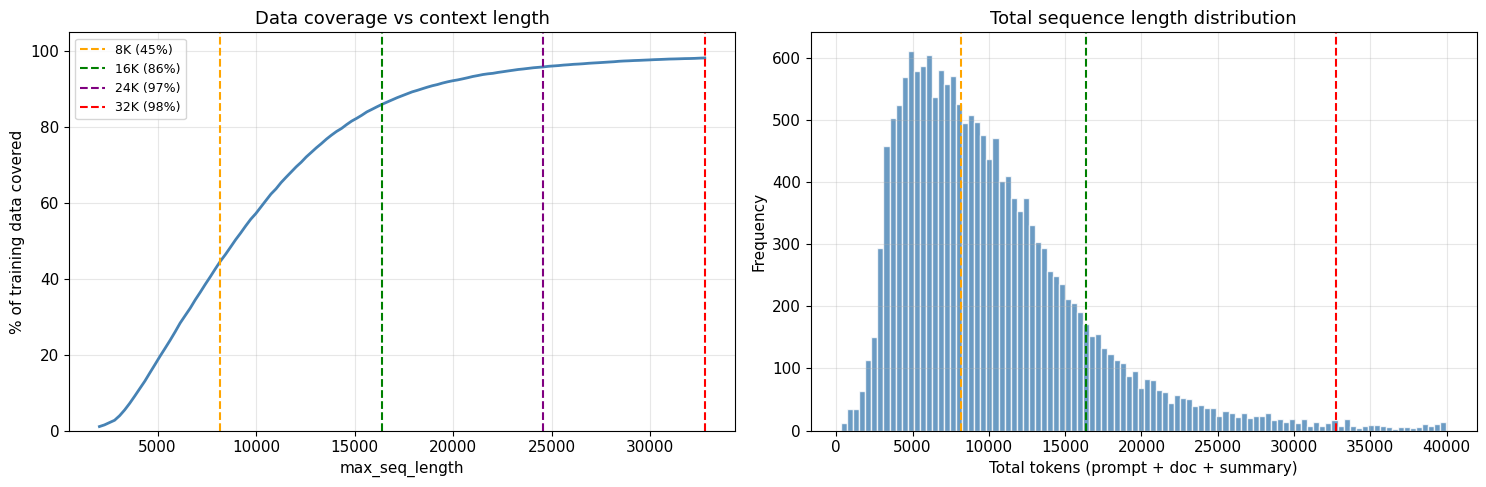

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Coverage curve
ax = axes[0]
thresholds = np.arange(2048, 33000, 256)
counts = [(total_tokens <= t).sum() for t in thresholds]
ax.plot(thresholds, [c/len(train)*100 for c in counts], color="steelblue", lw=2)
for limit, color, label in [
    (8192, "orange", "8K (45%)"), (16384, "green", "16K (86%)"),
    (24576, "purple", "24K (97%)"), (32768, "red", "32K (98%)"),
]:
    n = (total_tokens <= limit).sum()
    ax.axvline(limit, color=color, ls="--", lw=1.5, label=f"{label}")
ax.set_xlabel("max_seq_length"); ax.set_ylabel("% of training data covered")
ax.set_title("Data coverage vs context length")
ax.legend(fontsize=9); ax.set_ylim(0, 105)

# Total token distribution
ax = axes[1]
ax.hist(total_tokens[total_tokens <= 40000], bins=100, color="steelblue", edgecolor="white", alpha=0.8)
for limit, color in [(8192, "orange"), (16384, "green"), (32768, "red")]:
    ax.axvline(limit, color=color, ls="--", lw=1.5)
ax.set_xlabel("Total tokens (prompt + doc + summary)")
ax.set_ylabel("Frequency")
ax.set_title("Total sequence length distribution")

plt.tight_layout(); plt.show()

**Takeaway**: 
- At 16K we cover **86%** of data — good trade-off between coverage and GPU memory
- At 32K we cover **98%** — nearly everything, but 2x the memory cost
- The curve flattens after 16K — diminishing returns
- Only ~300 samples (1.8%) exceed 32K — these are extreme outliers to skip

**GPU memory consideration**: With Unsloth + QLoRA 4-bit + gradient checkpointing, a single 24GB GPU (e.g. RTX 3090/4090) can typically handle:
- `max_seq=8192` comfortably with batch_size=2
- `max_seq=16384` with batch_size=1
- `max_seq=32768` may need gradient accumulation or A100

---
## 2. Document & summary length characteristics

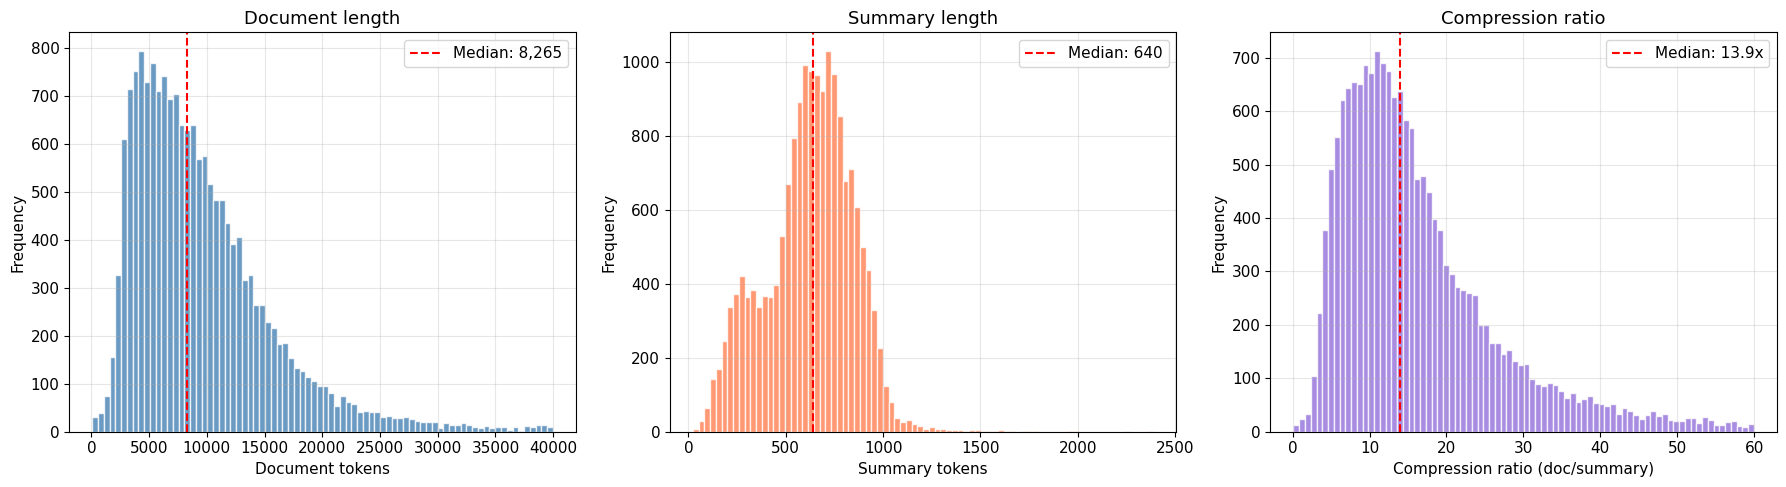

Documents are LONG — this is the defining characteristic of GovReport:
  Median doc: 8,265 tokens (8K)
  75th pctile: 12,469 tokens (12K)
  Summaries are substantial: median 640 tokens (~492 words)
  Compression: 14x median — highly abstractive summarization


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Doc length distribution
ax = axes[0]
ax.hist(doc_tokens[doc_tokens <= 40000], bins=80, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(np.median(doc_tokens), color="red", ls="--", label=f"Median: {np.median(doc_tokens):,.0f}")
ax.set_xlabel("Document tokens"); ax.set_ylabel("Frequency")
ax.set_title("Document length"); ax.legend()

# Summary length distribution
ax = axes[1]
ax.hist(sum_tokens, bins=80, color="coral", edgecolor="white", alpha=0.8)
ax.axvline(np.median(sum_tokens), color="red", ls="--", label=f"Median: {np.median(sum_tokens):,.0f}")
ax.set_xlabel("Summary tokens"); ax.set_ylabel("Frequency")
ax.set_title("Summary length"); ax.legend()

# Compression ratio
ax = axes[2]
ax.hist(compression[compression <= 60], bins=80, color="mediumpurple", edgecolor="white", alpha=0.8)
ax.axvline(np.median(compression), color="red", ls="--", label=f"Median: {np.median(compression):.1f}x")
ax.set_xlabel("Compression ratio (doc/summary)"); ax.set_ylabel("Frequency")
ax.set_title("Compression ratio"); ax.legend()

plt.tight_layout(); plt.show()

print("Documents are LONG — this is the defining characteristic of GovReport:")
print(f"  Median doc: {np.median(doc_tokens):,.0f} tokens ({np.median(doc_tokens)/1024:.0f}K)")
print(f"  75th pctile: {np.percentile(doc_tokens, 75):,.0f} tokens ({np.percentile(doc_tokens, 75)/1024:.0f}K)")
print(f"  Summaries are substantial: median {np.median(sum_tokens):,.0f} tokens (~{np.median(sum_tokens)/1.3:.0f} words)")
print(f"  Compression: {np.median(compression):.0f}x median — highly abstractive summarization")

---
## 3. Data quality: what to filter out?

In [7]:
# Identify problematic samples
print("Quality checks:\n")

# 1. Very short summaries (too little training signal)
short_sum = sum_tokens < 50
print(f"1. Summary < 50 tokens:     {short_sum.sum():>5} ({100*short_sum.sum()/len(train):.2f}%)")

# 2. Very short docs (not meaningful long-doc summarization)
short_doc = doc_tokens < 200
print(f"2. Doc < 200 tokens:        {short_doc.sum():>5} ({100*short_doc.sum()/len(train):.2f}%)")

# 3. Near-identity: summary ≈ doc (compression < 1.5)
identity = compression < 1.5
print(f"3. Compression < 1.5x:      {identity.sum():>5} ({100*identity.sum()/len(train):.2f}%)  (summary ≈ doc)")

# 4. Extremely long (won't fit in 32K)
too_long = total_tokens > 32768
print(f"4. Total > 32K tokens:      {too_long.sum():>5} ({100*too_long.sum()/len(train):.2f}%)  (overflow model context)")

# 5. Very long summaries (unusual)
long_sum = sum_tokens > 1500
print(f"5. Summary > 1500 tokens:   {long_sum.sum():>5} ({100*long_sum.sum()/len(train):.2f}%)")

# Combined filter
bad = short_sum | short_doc | identity | too_long
good = ~bad
print(f"\nSamples to REMOVE (union):  {bad.sum():>5} ({100*bad.sum()/len(train):.2f}%)")
print(f"Samples to KEEP:            {good.sum():>5} ({100*good.sum()/len(train):.1f}%)")
print(f"\n→ Very little noise. Only {bad.sum()} samples need filtering.")

Quality checks:

1. Summary < 50 tokens:         7 (0.04%)
2. Doc < 200 tokens:            9 (0.05%)
3. Compression < 1.5x:         33 (0.19%)  (summary ≈ doc)
4. Total > 32K tokens:        307 (1.75%)  (overflow model context)
5. Summary > 1500 tokens:      21 (0.12%)

Samples to REMOVE (union):    347 (1.98%)
Samples to KEEP:            17170 (98.0%)

→ Very little noise. Only 347 samples need filtering.


In [8]:
# Look at some of the bad samples to confirm they should be removed
for label, mask in [("Near-identity (compression < 1.5)", identity), ("Very short doc", short_doc)]:
    idx_list = np.where(mask)[0][:3]
    if len(idx_list) == 0:
        continue
    print(f"\n{'='*70}")
    print(f"  Examples: {label}")
    print(f"{'='*70}")
    for idx in idx_list:
        ex = train[int(idx)]
        print(f"\n  idx={idx} | doc={doc_tokens[idx]:,} toks | sum={sum_tokens[idx]:,} toks | ratio={compression[idx]:.1f}x")
        print(f"  Doc:     {ex['report'][:200]}...")
        print(f"  Summary: {ex['summary'][:200]}...")


  Examples: Near-identity (compression < 1.5)

  idx=349 | doc=1,095 toks | sum=866 toks | ratio=1.3x
  Doc:     While NARA’s fiscal year 2011 expenditure plan meets four of the six legislative conditions, the lack of critical capital planning and oversight steps—including documentation demonstrating approval of...
  Summary: Since 2001, the National Archives and Records Administration (NARA) has been working to develop an Electronic Records Archive (ERA) to preserve and provide access to massive volumes of all types of el...

  idx=404 | doc=177 toks | sum=685 toks | ratio=0.3x
  Doc:     For further information regarding this testimony, please contact Seto J. Bagdoyan, (202) 512-6722 or bagdoyans@gao.gov. In addition, contact points for our Offices of Congressional Relations and Publi...
  Summary: This testimony summarizes the information contained in GAO's April 2017 report, entitled SSA Disability Benefits: Comprehensive Strategic Approach Needed to Enhance Antifraud Activities (

---
## 4. Summary characteristics: extractive vs abstractive?

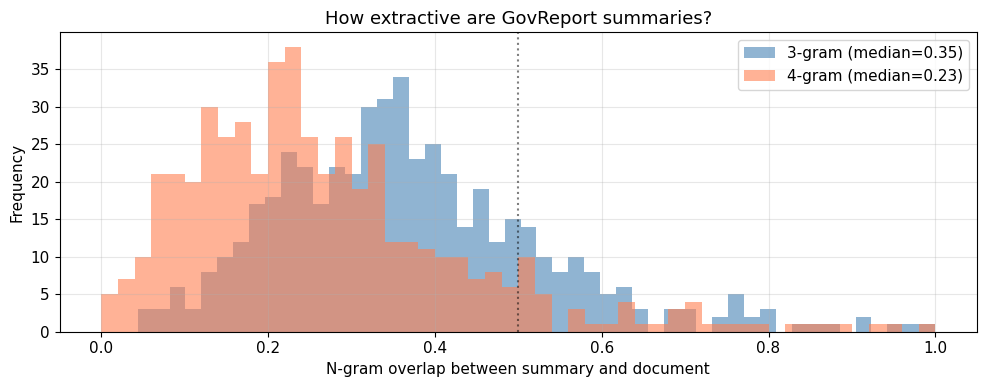

3-gram extractiveness: median=0.35, mean=0.37
4-gram extractiveness: median=0.23, mean=0.27

→ GovReport summaries are mixed (both extractive and abstractive)
  This means: the model needs to both copy key phrases AND rephrase/restructure.
  ROUGE scores will be moderate (not very high) because of the abstractive component.


In [9]:
def ngram_overlap(text_a, text_b, n=3):
    """Fraction of n-grams in text_b that appear in text_a."""
    words_a = text_a.lower().split()
    words_b = text_b.lower().split()
    if len(words_b) < n:
        return 0.0
    ngrams_a = set(tuple(words_a[i:i+n]) for i in range(len(words_a)-n+1))
    ngrams_b = [tuple(words_b[i:i+n]) for i in range(len(words_b)-n+1)]
    if not ngrams_b:
        return 0.0
    return sum(1 for ng in ngrams_b if ng in ngrams_a) / len(ngrams_b)

# Sample 500 for extractiveness analysis
np.random.seed(42)
sample_idx = np.random.choice(np.where(good)[0], size=500, replace=False)

extractiveness_3 = np.array([ngram_overlap(train[int(i)]["report"], train[int(i)]["summary"], n=3) for i in sample_idx])
extractiveness_4 = np.array([ngram_overlap(train[int(i)]["report"], train[int(i)]["summary"], n=4) for i in sample_idx])

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(extractiveness_3, bins=50, alpha=0.6, color="steelblue", label=f"3-gram (median={np.median(extractiveness_3):.2f})")
ax.hist(extractiveness_4, bins=50, alpha=0.6, color="coral", label=f"4-gram (median={np.median(extractiveness_4):.2f})")
ax.axvline(0.5, color="black", ls=":", alpha=0.5)
ax.set_xlabel("N-gram overlap between summary and document")
ax.set_ylabel("Frequency")
ax.set_title("How extractive are GovReport summaries?")
ax.legend(); plt.tight_layout(); plt.show()

print(f"3-gram extractiveness: median={np.median(extractiveness_3):.2f}, mean={extractiveness_3.mean():.2f}")
print(f"4-gram extractiveness: median={np.median(extractiveness_4):.2f}, mean={extractiveness_4.mean():.2f}")
print()
style = "mixed (both extractive and abstractive)" if 0.2 < np.median(extractiveness_3) < 0.6 else \
        "mostly extractive" if np.median(extractiveness_3) >= 0.6 else "mostly abstractive"
print(f"→ GovReport summaries are {style}")
print(f"  This means: the model needs to both copy key phrases AND rephrase/restructure.")
print(f"  ROUGE scores will be moderate (not very high) because of the abstractive component.")

---
## 5. Positional analysis: where does summary content come from?

This matters for:
- Understanding **primacy bias** (does the model only attend to the beginning?)
- Justifying the **agent pipeline** (chunking helps if content is spread across the doc)

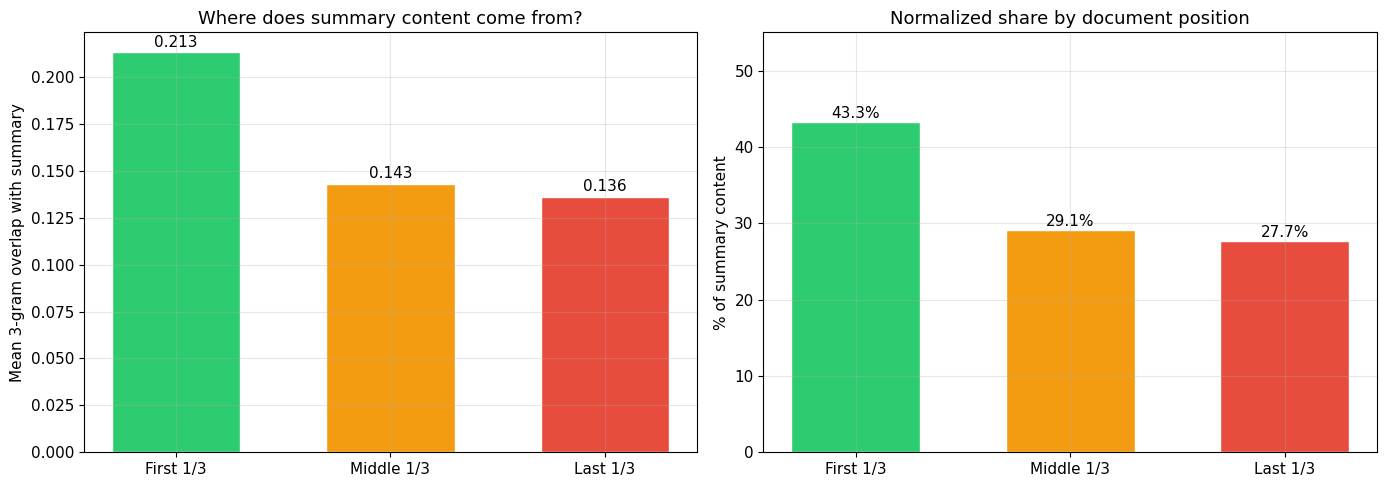

Summary content is spread across the ENTIRE document:
  First 1/3:  43.3%
  Middle 1/3: 29.1%
  Last 1/3:   27.7%

→ Roughly 43/30/27 split — beginning is most important but ALL parts matter.
→ This confirms: the model must attend to the full document.
→ Agent pipeline value: chunking ensures no part of a long doc is ignored.


In [10]:
overlap_by_position = {pos: [] for pos in ["First 1/3", "Middle 1/3", "Last 1/3"]}

for i in sample_idx:
    doc = train[int(i)]["report"]
    summary = train[int(i)]["summary"]
    words = doc.split()
    third = len(words) // 3
    
    overlap_by_position["First 1/3"].append(ngram_overlap(" ".join(words[:third]), summary))
    overlap_by_position["Middle 1/3"].append(ngram_overlap(" ".join(words[third:2*third]), summary))
    overlap_by_position["Last 1/3"].append(ngram_overlap(" ".join(words[2*third:]), summary))

for k in overlap_by_position:
    overlap_by_position[k] = np.array(overlap_by_position[k])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
ax = axes[0]
positions = list(overlap_by_position.keys())
means = [overlap_by_position[p].mean() for p in positions]
colors = ["#2ecc71", "#f39c12", "#e74c3c"]
bars = ax.bar(positions, means, color=colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{val:.3f}", ha="center", fontsize=11)
ax.set_ylabel("Mean 3-gram overlap with summary")
ax.set_title("Where does summary content come from?")

# Normalized share
ax = axes[1]
total_by_sample = overlap_by_position["First 1/3"] + overlap_by_position["Middle 1/3"] + overlap_by_position["Last 1/3"]
safe = total_by_sample > 0
shares = [overlap_by_position[p][safe].sum() / total_by_sample[safe].sum() * 100 for p in positions]
bars = ax.bar(positions, shares, color=colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, shares):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", fontsize=11)
ax.set_ylabel("% of summary content")
ax.set_title("Normalized share by document position")
ax.set_ylim(0, 55)

plt.tight_layout(); plt.show()

print(f"Summary content is spread across the ENTIRE document:")
print(f"  First 1/3:  {shares[0]:.1f}%")
print(f"  Middle 1/3: {shares[1]:.1f}%")
print(f"  Last 1/3:   {shares[2]:.1f}%")
print(f"\n→ Roughly 43/30/27 split — beginning is most important but ALL parts matter.")
print(f"→ This confirms: the model must attend to the full document.")
print(f"→ Agent pipeline value: chunking ensures no part of a long doc is ignored.")

---
## 6. Token budget analysis for training

In [11]:
# For different max_seq_length options, analyze the filtered dataset

for MSL in [8192, 16384, 32768]:
    m = good & (total_tokens <= MSL)
    n = m.sum()
    fd = doc_tokens[m]
    fs = sum_tokens[m]
    ft = total_tokens[m]
    
    doc_share = fd / (ft - OVERHEAD) * 100
    sum_share = fs / (ft - OVERHEAD) * 100
    waste = MSL - ft  # unused tokens (padding)
    
    print(f"{'='*65}")
    print(f"  max_seq_length = {MSL:,} | {n:,} samples ({100*n/len(train):.1f}% of data)")
    print(f"{'='*65}")
    print(f"  Doc tokens:     {pct(fd)}")
    print(f"  Sum tokens:     {pct(fs)}")
    print(f"  Doc share:      median={np.median(doc_share):.0f}%  mean={doc_share.mean():.0f}%")
    print(f"  Sum share:      median={np.median(sum_share):.0f}%  mean={sum_share.mean():.0f}%")
    print(f"  Padding waste:  median={np.median(waste):,.0f} ({100*np.median(waste)/MSL:.0f}% of max_seq)")
    print(f"  P95 summary:    {np.percentile(fs, 95):,.0f} tokens → set max_new_tokens >= {int(np.percentile(fs, 95)) + 64}")
    print()

  max_seq_length = 8,192 | 7,788 samples (44.5% of data)
  Doc tokens:     N=7,788  P5=2,304  P25=3,592  P50=4,854  P75=6,177  P95=7,272  mean=4,847
  Sum tokens:     N=7,788  P5=179  P25=373  P50=577  P75=727  P95=917  mean=559
  Doc share:      median=90%  mean=89%
  Sum share:      median=10%  mean=11%
  Padding waste:  median=2,722 (33% of max_seq)
  P95 summary:    917 tokens → set max_new_tokens >= 981

  max_seq_length = 16,384 | 15,026 samples (85.8% of data)
  Doc tokens:     N=15,026  P5=2,724  P25=4,766  P50=7,360  P75=10,474  P95=14,170  mean=7,761
  Sum tokens:     N=15,026  P5=213  P25=472  P50=632  P75=769  P95=940  mean=611
  Doc share:      median=93%  mean=91%
  Sum share:      median=7%  mean=9%
  Padding waste:  median=8,393 (51% of max_seq)
  P95 summary:    940 tokens → set max_new_tokens >= 1004

  max_seq_length = 32,768 | 17,170 samples (98.0% of data)
  Doc tokens:     N=17,170  P5=2,825  P25=5,130  P50=8,175  P75=12,209  P95=20,267  mean=9,335
  Sum tokens:  

---
## 7. Cross-split consistency

In [12]:
# Tokenize val/test properly (not approximation)
for split_name in ["validation", "test"]:
    split = ds[split_name]
    dtoks = np.array([len(tokenizer.encode(ex["report"], add_special_tokens=False)) for ex in split])
    stoks = np.array([len(tokenizer.encode(ex["summary"], add_special_tokens=False)) for ex in split])
    ttoks = OVERHEAD + dtoks + stoks
    
    for MSL in [16384, 32768]:
        fits = (ttoks <= MSL).sum()
        print(f"  {split_name:<12} max_seq={MSL:>6,}: {fits:>4}/{len(split)} ({100*fits/len(split):.1f}%) fit")
    print()

print("→ Val/test have similar coverage rates to train — splits are consistent.")

  validation   max_seq=16,384:  822/973 (84.5%) fit
  validation   max_seq=32,768:  960/973 (98.7%) fit



  test         max_seq=16,384:  851/973 (87.5%) fit
  test         max_seq=32,768:  966/973 (99.3%) fit

→ Val/test have similar coverage rates to train — splits are consistent.


---
## 8. Final decision & dataset profile

In [13]:
# ═══════════════════════════════════════════════════════════════
#  DECISION
# ═══════════════════════════════════════════════════════════════
#
#  max_seq_length = 16384 (recommended) or 32768 (if GPU allows)
#
#  Rationale:
#  1. This is LONG-DOCUMENT summarization — truncation defeats the purpose
#  2. At 16K: 86% coverage with reasonable GPU memory (batch=1 on 24GB)
#  3. At 32K: 98% coverage but needs A100 or careful memory management
#  4. Quality filters remove only ~350 bad samples (2%)
#  5. GovReport summaries are mixed extractive/abstractive
#  6. Content comes from ALL parts of the doc → full context needed
#
#  Strategy: FILTER (quality + context overflow), NO truncation
# ═══════════════════════════════════════════════════════════════

# Two configs depending on GPU
for MSL, gpu_note in [(16384, "24GB GPU (RTX 3090/4090)"), (32768, "48GB+ GPU (A100/A6000)")]:
    m = good & (total_tokens <= MSL)
    N = m.sum()
    fd = doc_tokens[m]
    fs = sum_tokens[m]
    ft = total_tokens[m]
    
    print(f"{'='*70}")
    print(f"  CONFIG: max_seq_length = {MSL:,}  ({gpu_note})")
    print(f"{'='*70}")
    print(f"  Samples:        {N:,} / {len(train):,} ({100*N/len(train):.1f}%)")
    print(f"  Doc tokens:     median={np.median(fd):,.0f}  P95={np.percentile(fd, 95):,.0f}")
    print(f"  Sum tokens:     median={np.median(fs):,.0f}  P95={np.percentile(fs, 95):,.0f}")
    print(f"  max_new_tokens: {int(np.percentile(fs, 95)) + 64}")
    print()
    print(f"  prepare_data.py:")
    print(f"    --max-seq-length {MSL}")
    print(f"    --min-doc-tokens 200")
    print(f"    --min-sum-tokens 50")
    print(f"    --min-compression 1.5")
    print()

print("NOTE: The agent pipeline handles docs that exceed max_seq_length at inference")
print("time by chunking → summarize-per-chunk → merge. So the model only needs to")
print("learn to summarize docs up to max_seq_length; the pipeline handles the rest.")

  CONFIG: max_seq_length = 16,384  (24GB GPU (RTX 3090/4090))
  Samples:        15,026 / 17,517 (85.8%)
  Doc tokens:     median=7,360  P95=14,170
  Sum tokens:     median=632  P95=940
  max_new_tokens: 1004

  prepare_data.py:
    --max-seq-length 16384
    --min-doc-tokens 200
    --min-sum-tokens 50
    --min-compression 1.5

  CONFIG: max_seq_length = 32,768  (48GB+ GPU (A100/A6000))
  Samples:        17,170 / 17,517 (98.0%)
  Doc tokens:     median=8,175  P95=20,267
  Sum tokens:     median=639  P95=946
  max_new_tokens: 1010

  prepare_data.py:
    --max-seq-length 32768
    --min-doc-tokens 200
    --min-sum-tokens 50
    --min-compression 1.5

NOTE: The agent pipeline handles docs that exceed max_seq_length at inference
time by chunking → summarize-per-chunk → merge. So the model only needs to
learn to summarize docs up to max_seq_length; the pipeline handles the rest.


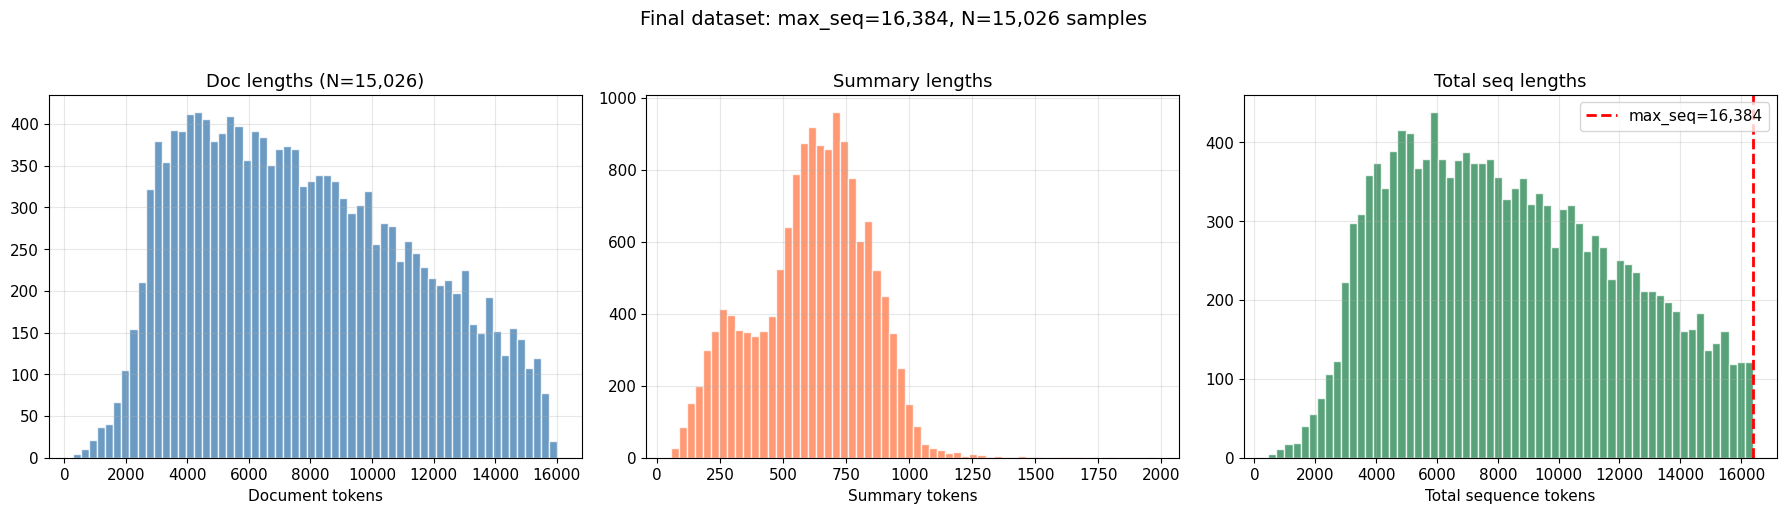

In [14]:
# Final visualization: the recommended dataset (16K)
MSL = 16384
m = good & (total_tokens <= MSL)
fd = doc_tokens[m]; fs = sum_tokens[m]; ft = total_tokens[m]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(fd, bins=60, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Document tokens"); axes[0].set_title(f"Doc lengths (N={m.sum():,})")

axes[1].hist(fs, bins=60, color="coral", edgecolor="white", alpha=0.8)
axes[1].set_xlabel("Summary tokens"); axes[1].set_title("Summary lengths")

axes[2].hist(ft, bins=60, color="seagreen", edgecolor="white", alpha=0.8)
axes[2].axvline(MSL, color="red", ls="--", lw=2, label=f"max_seq={MSL:,}")
axes[2].set_xlabel("Total sequence tokens"); axes[2].set_title("Total seq lengths")
axes[2].legend()

plt.suptitle(f"Final dataset: max_seq={MSL:,}, N={m.sum():,} samples", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

In [15]:
# Show 2 representative examples
final_idx = np.where(m)[0]
sorted_final = final_idx[np.argsort(doc_tokens[m])]

for label, idx in [("MEDIAN-LENGTH DOC", sorted_final[len(sorted_final)//2]),
                    ("LONG DOC (near 16K)", sorted_final[-10])]:
    ex = train[int(idx)]
    dt, st = doc_tokens[idx], sum_tokens[idx]
    
    print(f"\n{'='*80}")
    print(f"  {label} | doc={dt:,} toks | sum={st:,} toks | total={dt+st+OVERHEAD:,}/{MSL:,}")
    print(f"{'='*80}")
    print(f"\n  Doc (first 500 chars): {ex['report'][:500]}")
    print(f"\n  Summary (first 500 chars): {ex['summary'][:500]}")
    if len(ex['summary']) > 500:
        print(f"  ...({len(ex['summary'])-500:,} chars more)")


  MEDIAN-LENGTH DOC | doc=7,360 toks | sum=691 toks | total=8,060/16,384

  Doc (first 500 chars): The National Forest System (NFS) is administered by the Forest Service (FS) in the U.S. Department of Agriculture (USDA). The NFS is comprised of national forests, national grasslands, and various other designations. Although 87% of NFS lands are in the West, the FS administers more federal land in the East than all other federal agencies combined. NFS lands are administered for sustained yields of multiple uses, including outdoor recreation (camping, hiking, hunting, sightseeing, etc.), livesto

  Summary (first 500 chars): The 193 million acres of the National Forest System (NFS) comprise 154 national forests, 20 national grasslands, and several other federal land designations. Management of the NFS is one of the three principal responsibilities of the Forest Service (FS), an agency within the U.S. Department of Agriculture (USDA). The other two principal responsibilities are providing